In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skdim
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
import rioxarray
# add ../ to the path
import sys
sys.path.append('../')

def save_to_geotiff(data, x_coord, y_coord, filename):
    # Create an xarray DataArray
    da = xr.DataArray(data, coords=[('y', y_coord), ('x', x_coord)])
    
    # Save to GeoTIFF using rioxarray
    da.rio.to_raster(filename)

%load_ext autoreload
%autoreload 2

# load data
# get the DATA_PATH from the environment variable
data_path  = os.getenv('DATA_PATH')
param_path = os.getenv('PARAM_PATH')
folder = data_path
X_filename = 'trainingAll4D_Eb_sim_standardized.mat'
Y_filename = 'trainingAll4D_Ns_sim_masked_standardized.mat'
H_filename = 'H_gridded.mat'
mask_filename = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename = 'trainingAll_Ns_sim_std_masked.mat'
coord_filename = "trainingAll_image_coord.mat"
# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


X_data = scipy.io.loadmat(folder + X_filename)
Y_data = scipy.io.loadmat(folder + Y_filename)
mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename)
coord_data = scipy.io.loadmat(folder + coord_filename)

Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704


Shape of Eb_standardized: (256, 256, 1, 1042)
Shape of Ns_standardized: (256, 256, 1, 1042)
Shape of mask: (256, 256)


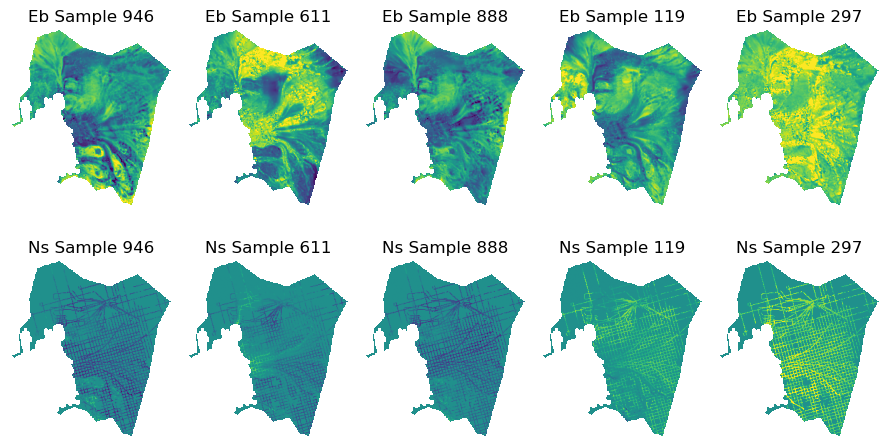

In [3]:
x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

Eb_standardized = X_data['Eb_standardized']
Ns_standardized = Y_data['Ns_standardized_masked']
mask = mask_data['mask']
mask_bool = mask.astype(bool)
print('Shape of Eb_standardized:', Eb_standardized.shape)
print('Shape of Ns_standardized:', Ns_standardized.shape)
print('Shape of mask:', mask.shape)

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(float)
  
# plot three random samples (Eb and Ns) for visual
num_samples = Eb_standardized.shape[3]
random_indices = np.random.choice(num_samples, size=5, replace=False)
# figure size
plt.figure(figsize=(9, 5))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    Eb_plot = Eb_standardized[:, :, :, idx].copy()
    Eb_plot[model_bound_data_ori == 0] = np.nan # set the values outside the model boundary to NaN for better visualization
    plt.imshow(Eb_plot, cmap='viridis', vmin = -2, vmax = 2, extent=extent)
    plt.gca().invert_yaxis()
    plt.gca().axis('off')
    plt.title(f'Eb Sample {idx}')
    # plt.colorbar()
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 6)
    
    Ns_plot = Ns_standardized[:, :, 0, idx].copy()  # shape (256, 256) ✅
    # Ns_plot[~mask_bool] = np.nan
    Ns_plot[model_bound_data_ori == 0] = np.nan
    
    plt.imshow(Ns_plot, cmap='viridis', vmin=-2, vmax=2, extent=extent)
    plt.gca().invert_yaxis()
    plt.gca().axis('off')
    plt.title(f'Ns Sample {idx}')

plt.tight_layout()
plt.savefig('../figs/sample_Eb_Ns.png', dpi=300)
plt.show()

### Investigate the relationship between ensemble size and intrinsic dimension

shape of data_reshaped: (1042, 65536)


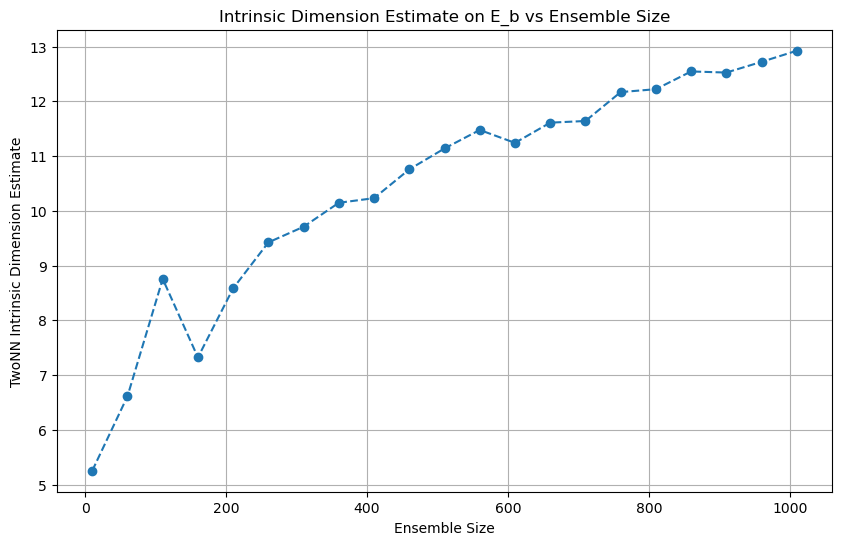

In [4]:
# randomly shuffle data_reshaped
# apply the same analysis to Eb_standardized data, which now has dimension (nx, ny, 1, n_samples) where nx*ny is the full spatial dimension for each sample
nx, ny, _, n_samples = Eb_standardized.shape
data_reshaped = Eb_standardized.reshape((nx * ny, n_samples)).T
print('shape of data_reshaped:', data_reshaped.shape)

np.random.seed(0)
shuffled_indices = np.random.permutation(data_reshaped.shape[0])
data_shuffled = data_reshaped[shuffled_indices]

ensemble_size = range(10, n_samples + 1, 50)
townn_estimates = []

for size in ensemble_size:
    subset = data_shuffled[:size,:]
    twonn = skdim.id.TwoNN().fit(subset)
    townn_estimates.append(twonn.dimension_)

# Plot intrinsic dimension estimates vs ensemble size
plt.figure(figsize=(10, 6))
plt.plot(ensemble_size, townn_estimates, marker='o', linestyle='--')
plt.xlabel('Ensemble Size')
plt.ylabel('TwoNN Intrinsic Dimension Estimate')
plt.title('Intrinsic Dimension Estimate on E_b vs Ensemble Size')
plt.grid()
plt.show()

### Compare PCA to the intrinsic dimension estimates

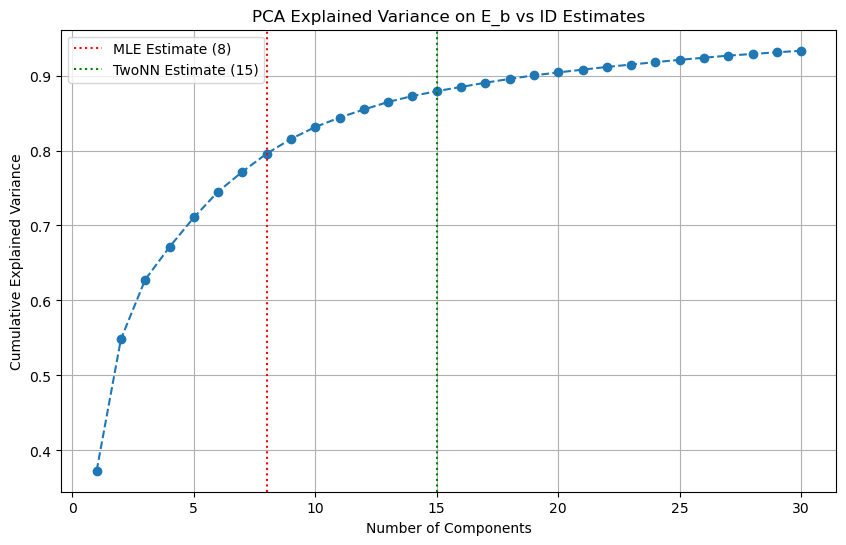

Variance at 8 dims: 0.796
Variance at 15 dims: 0.879


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA
pca = PCA(n_components=30) # Look at top 30
pca.fit(data_reshaped)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), cumulative_variance, marker='o', linestyle='--')
plt.axvline(x=8, color='r', linestyle=':', label='MLE Estimate (8)')
plt.axvline(x=15, color='g', linestyle=':', label='TwoNN Estimate (15)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance on E_b vs ID Estimates')
plt.legend()
plt.grid(True)
plt.show()

# Check values
print(f"Variance at 8 dims: {cumulative_variance[7]:.3f}")
print(f"Variance at 15 dims: {cumulative_variance[14]:.3f}")


shape of X_reshaped: (1042, 65536)
shape of Y_reshaped: (1042, 65536)
Explained Variance (X): 0.904
Explained Variance (Y): 0.984


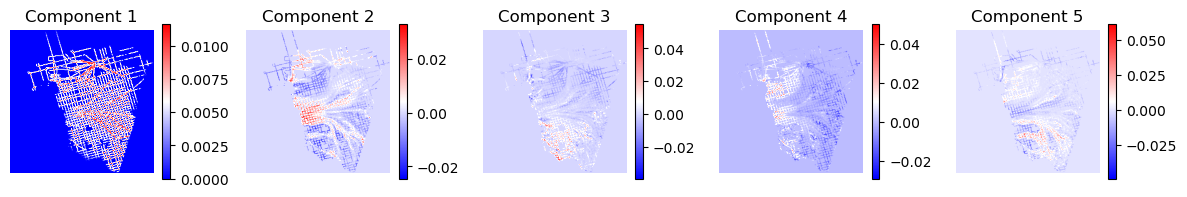

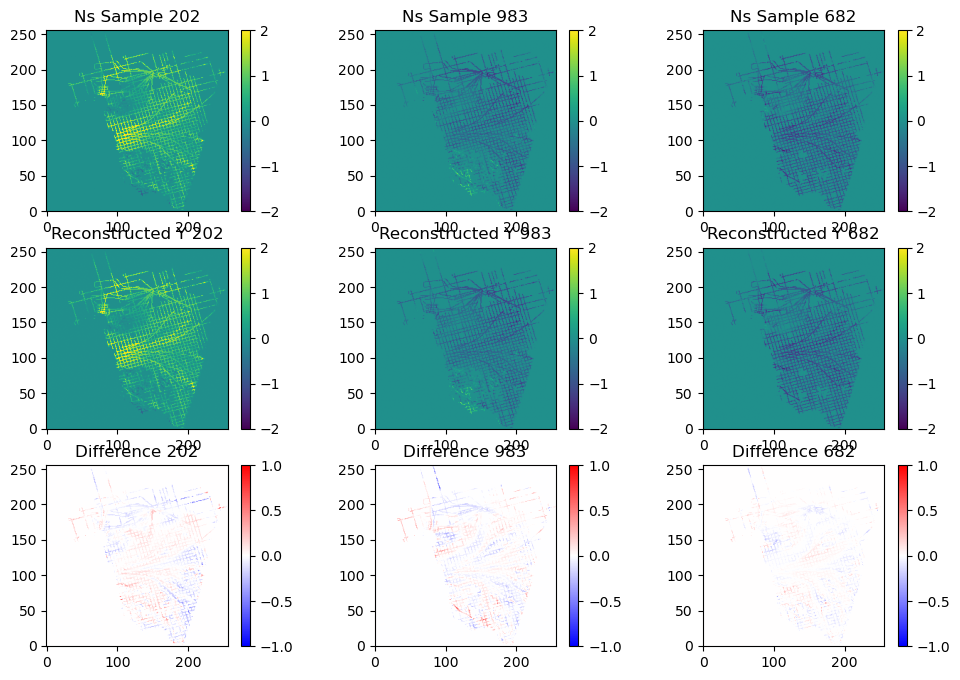

In [11]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


# apply the same analysis to Eb_standardized data, which now has dimension (nx, ny, 1, n_samples) where nx*ny is the full spatial dimension for each sample
nx, ny, _, n_samples = Eb_standardized.shape
X_reshaped = Eb_standardized.reshape((nx * ny, n_samples)).T
# Y_reshaped = Eb_standardized_masked.reshape((nx * ny, n_samples)).T
Y_reshaped = Ns_standardized.reshape((nx * ny, n_samples)).T
print('shape of X_reshaped:', X_reshaped.shape)
print('shape of Y_reshaped:', Y_reshaped.shape)

# 1. PCA Step: Compress 65k -> 18 dimensions
# We choose 18 to capture slightly more than the TwoNN estimate (buffer for curvature)
pca_X = PCA(n_components=20) 
X_reduced = pca_X.fit_transform(X_reshaped)

pca_Y = PCA(n_components=15)
Y_reduced = pca_Y.fit_transform(Y_reshaped)

print(f"Explained Variance (X): {np.sum(pca_X.explained_variance_ratio_):.3f}")
print(f"Explained Variance (Y): {np.sum(pca_Y.explained_variance_ratio_):.3f}")


# visualize the first 5 PCA components for Y
plt.figure(figsize=(12, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    component_img = pca_Y.components_[i].reshape((nx, ny))
    plt.imshow(component_img, cmap='bwr')
    plt.title(f'Component {i+1}')
    plt.colorbar()
    # turn off axis
    plt.gca().axis('off')
    plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../figs/pca_components_Y.png', dpi=300)
plt.show()

# check how well reconstructed Y_reduced using the PCA components learned from Eb_standardized_masked 
# can capture the variance in Ns_standardized
reconstructed_Y = pca_Y.inverse_transform(Y_reduced)  # shape (n_samples, 65536)

# visualize three random samples
random_indices = np.random.choice(n_samples, size=3, replace=False)
plt.figure(figsize=(12, 8))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(Ns_standardized[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Ns Sample {idx}')
    plt.gca().invert_yaxis()
    plt.colorbar()
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 4)
    plt.imshow(reconstructed_Y[idx].reshape(nx, ny), cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Reconstructed Y {idx}')
    plt.gca().invert_yaxis()
    plt.colorbar()
# difference
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 7)
    plt.imshow(Ns_standardized[:, :, :, idx].squeeze() - reconstructed_Y[idx].reshape(nx, ny), cmap='bwr', vmin = -1, vmax = 1)
    plt.title(f'Difference {idx}')
    plt.gca().invert_yaxis()
    plt.colorbar()

# Using Gaussian Mixture model on the latent space

In [12]:
from gmr.utils import check_random_state
from gmr import MVN, GMM, plot_error_ellipses
from gmr.mvn import regression_coefficients
from gmr.gmm import _safe_probability_density

from scipy.sparse.linalg import eigsh, LinearOperator
from scipy.spatial import cKDTree
import time

from src.amortization import form_obs_cov_col, build_spatial_covariance_operator, sample_from_spatial_cov, pushforward, propagate_uncertainty
from src.amortization import compute_conditional_expected_val, compute_conditional_std_val_latent
from src.utilities import standardize

#### Loading and training

In [13]:
ndim_X = X_reduced.shape[1]
ndim_Y = Y_reduced.shape[1]

random_state = check_random_state(42)
# mvn = GMM(n_components = 10, random_state=random_state)
mvn = MVN(random_state=random_state)

# combine the reduced dimension of X and Y along the column dimension
XY_reduced = np.hstack((Y_reduced, X_reduced))

# shuffle and split a subset for training (90%) and testing (10%)
n_samples = XY_reduced.shape[0]
indices = np.arange(n_samples)
random_state.shuffle(indices)
split_point = int(0.9 * n_samples)
train_indices = indices[:split_point]
test_indices = indices[split_point:]
XY_train = XY_reduced[train_indices]
XY_test = XY_reduced[test_indices]

ndim_X = X_reduced.shape[1]
ndim_Y = Y_reduced.shape[1]

random_state = check_random_state(42)
gmm = GMM(n_components=25, random_state=random_state)

# combine the reduced dimension of X and Y along the column dimension
# notice here that Y is before X, which means the first few dimensions are Y.T
# we need to be consistent later on when supplying the condition index during our inference stage.
XY_reduced = np.hstack((Y_reduced, X_reduced))

# shuffle and split a subset for training (90%) and testing (10%)
n_samples = XY_reduced.shape[0]
indices = np.arange(n_samples)
random_state.shuffle(indices)
split_point = int(0.9 * n_samples)
print("split point:", split_point)
train_indices = indices[:split_point]
test_indices = indices[split_point:]
XY_train = XY_reduced[train_indices]
XY_test = XY_reduced[test_indices]

print('shape of XY_train:', XY_train.shape)
print('shape of XY_test:', XY_test.shape)

# create GMM, P(Y,X)
# time the training time
start_time = time.time()
gmm.from_samples(XY_train)
end_time = time.time()
training_time = end_time - start_time
print(f"GMM training time: {training_time:.2f} seconds")




split point: 937
shape of XY_train: (937, 35)
shape of XY_test: (105, 35)
GMM training time: 0.14 seconds


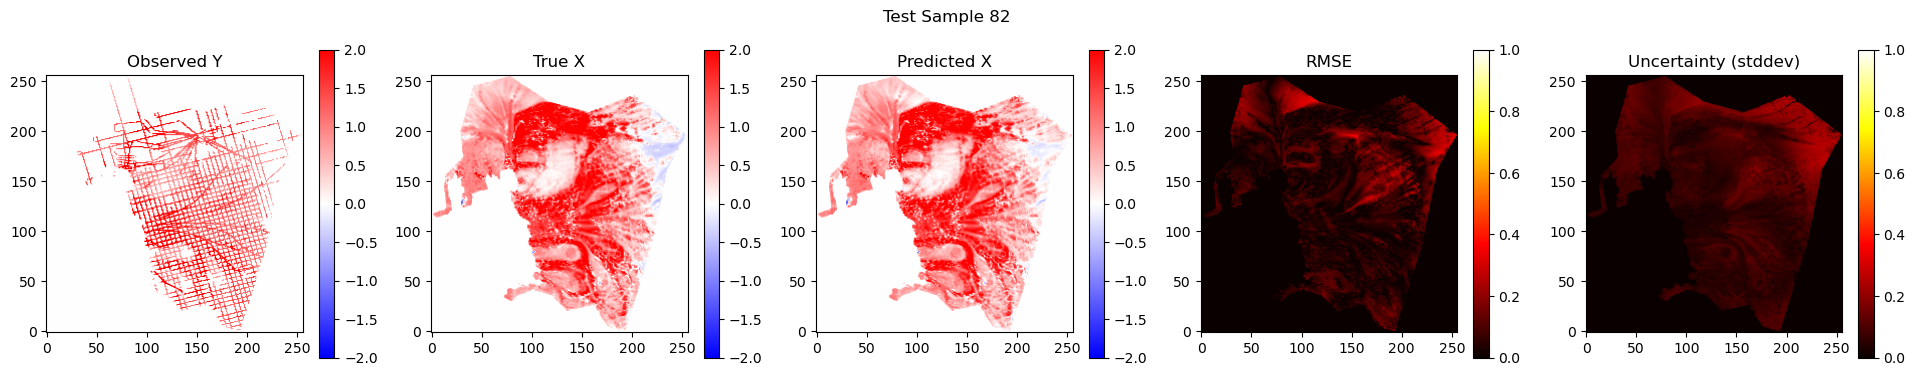

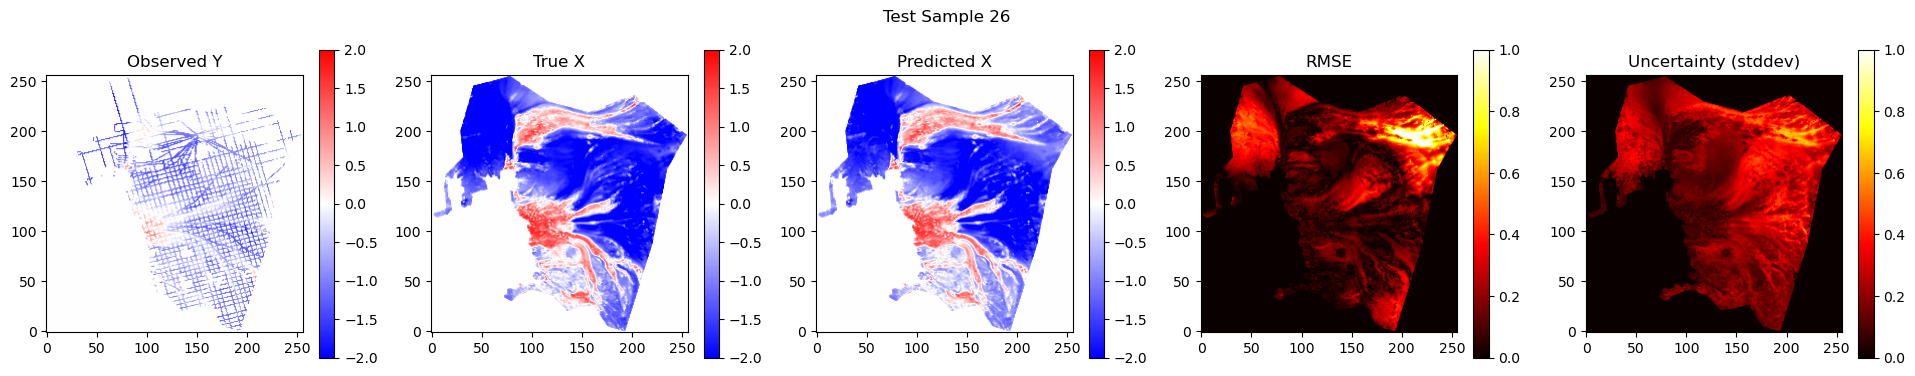

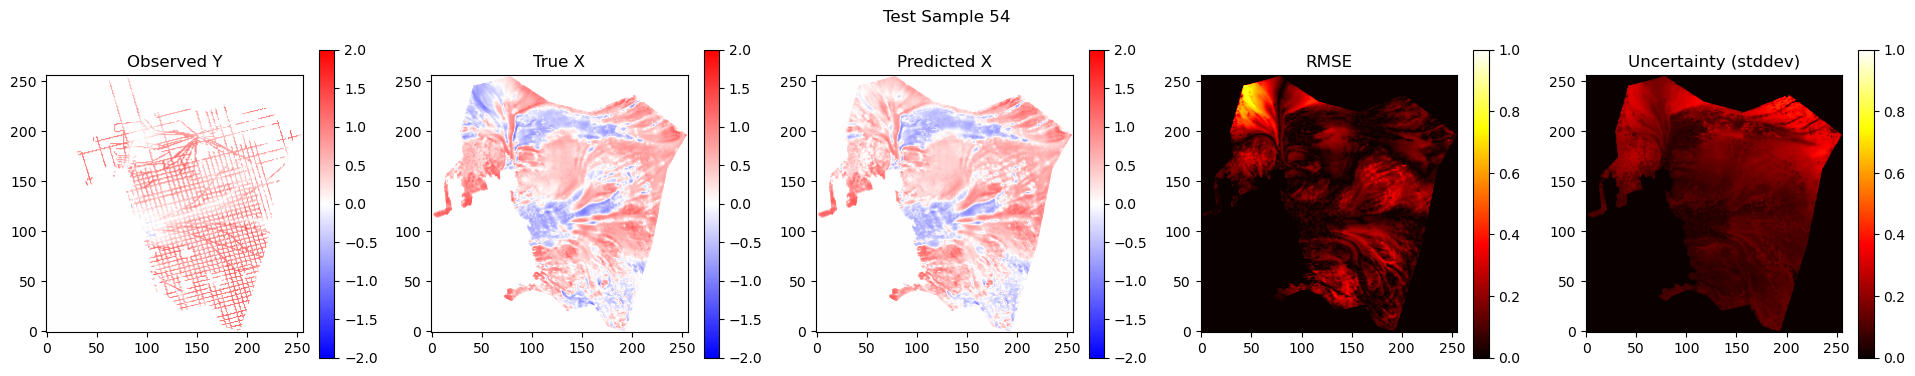

In [15]:

# test first three samples from the test set and visualize the prediction
n_test_samples = len(test_indices)
n_test_samples_plot = 3 
rand_idx = np.random.choice(range(n_test_samples), size=n_test_samples_plot, replace=False)
for i in rand_idx:
    y_test = XY_test[i, :ndim_Y]  # Y part
    x_test = XY_test[i, ndim_Y:]  # X part

    # Predict X given Y
    condition_index = np.arange(ndim_Y)
    x_pred_gmm = gmm.condition(condition_index, y_test)

    # sample from this conditional distribution to get uncertainty
    n_uq_sample = 400
    x_uq_samples = x_pred_gmm.sample(n_uq_sample)
    x_uq_samples_ori = np.zeros((256*256, n_uq_sample))
    # Inverse transform to original space
    # then the uq samples
    for j, sample in enumerate(x_uq_samples):
        x_uq_samples_ori[:,j] = pca_X.inverse_transform(sample)

    # compute the mean from the ensemble
    x_pred_mean = np.mean(x_uq_samples_ori, axis=1)
    x_pred_img = x_pred_mean.reshape(256, 256)
    
    # compute std along each dimension of the uq samples
    x_uq_std = np.std(x_uq_samples_ori, axis=1)
    x_uq_std = x_uq_std.reshape(256, 256)

    # Reshape X for visualization
    x_test_original = pca_X.inverse_transform(x_test.reshape(1, -1))
    x_test_img = x_test_original.reshape(256, 256)

    # observed Y
    obs_Y = pca_Y.inverse_transform(y_test)
    obs_Y = obs_Y.reshape(256, 256)
    # Plotting: five columns: observed Y, True X, predicted X, error (RMSE), uncertainty (stddev)
    plt.figure(figsize=(24, 4))
    plt.subplot(1, 5, 1)
    plt.imshow(obs_Y, cmap='bwr', vmin=-2, vmax=2)
    plt.title('Observed Y')
    plt.colorbar()
    # invert y axis
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 2)
    plt.imshow(x_test_img, cmap='bwr', vmin=-2, vmax=2)
    plt.title('True X')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 3)
    plt.imshow(x_pred_img, cmap='bwr', vmin=-2, vmax=2)
    plt.title('Predicted X')
    plt.colorbar()
    plt.gca().invert_yaxis()
    
    plt.subplot(1, 5, 4)
    rmse_img = np.sqrt((x_test_img - x_pred_img) ** 2)
    plt.imshow(rmse_img, cmap='hot', vmin = 0, vmax = 1)
    plt.title('RMSE')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 5)
    plt.imshow(x_uq_std, cmap='hot', vmin = 0, vmax = 1)
    plt.title('Uncertainty (stddev)')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.suptitle(f'Test Sample {i+1}')
    # save the figure, dpi = 300
    plt.savefig(f'../figs/test_sample_{i+1}_prediction.png', dpi=300)
    plt.show()

Using relaxation z-score standardization with epsilon = 0.262291780650704


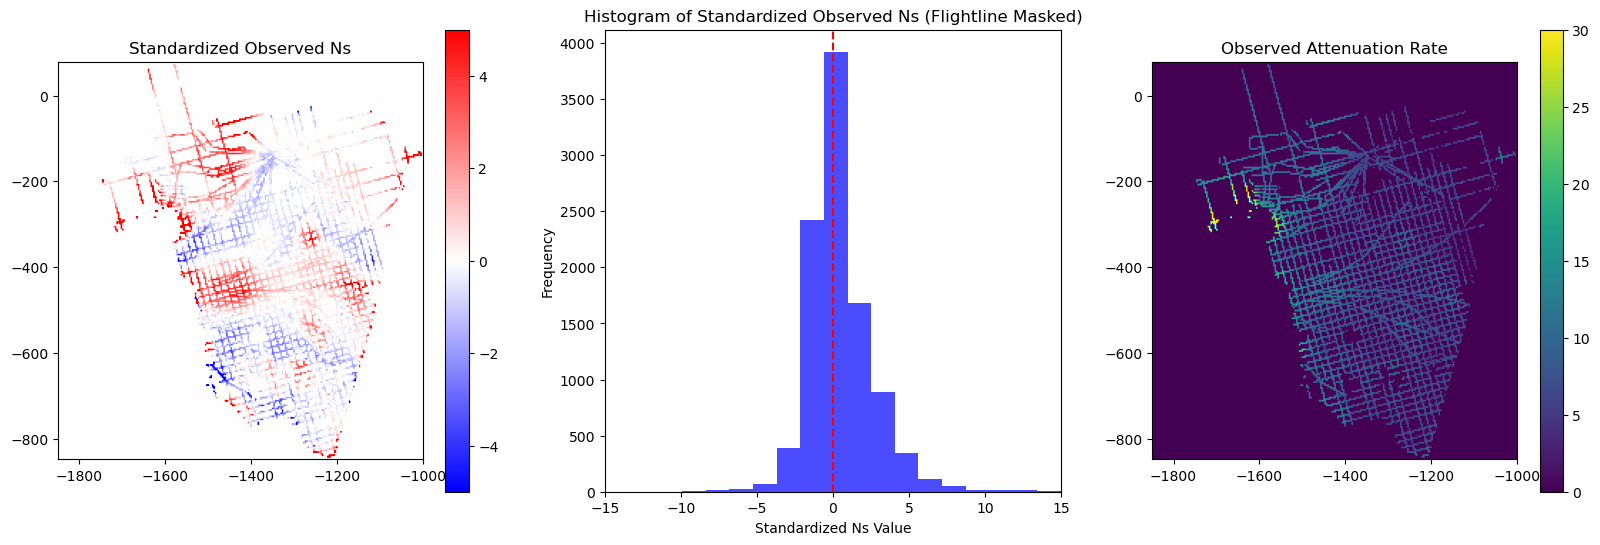

In [16]:
# load observed Y data
Y_obs_filename = "Ns_obs_gridded.mat"
Y_obs_data = scipy.io.loadmat(folder + Y_obs_filename)
Y_obs_data = Y_obs_data['atten_rate_grid']

atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# load Ns mean and std
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std_data = scipy.io.loadmat(folder + Ns_std_filename)
Ns_std = Ns_std_data['Ns_std_masked']  

# apply flightline masking to the standardization mean and std
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~mask_bool] = 1 # set the std to 1

# standardize
Ns_obs_standardized = standardize(atten_rate_avg, Ns_mean_masked, Ns_std_masked,
                                  method='relaxation', epsilon=Ns_standardize_epsilon)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.imshow(Ns_obs_standardized, cmap='bwr', vmin=-5, vmax=5, extent=extent)
plt.title('Standardized Observed Ns')
plt.colorbar()
plt.gca().invert_yaxis()

# second plot: histogram of the standardized observed Ns
plt.subplot(1, 3, 2)
plt.hist(Ns_obs_standardized[mask_bool].flatten(), bins=50, color='blue', alpha=0.7)
plt.xlim(-15, 15)
# plot y line at x = 0
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Histogram of Standardized Observed Ns (Flightline Masked)')
plt.xlabel('Standardized Ns Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.imshow(atten_rate_avg, cmap='viridis', vmin=0, vmax=30, extent=extent)
plt.title('Observed Attenuation Rate')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

# assign new var
Y_obs_mean = Ns_obs_standardized.copy()


In [17]:
# sampling from the covariance explictly
# construct a covariance matrix for the observation to account for epstemic uncertainty
# we need the mask array and ice thickness array
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()

# build the linear operator for contructing covariance matrix sampling
Sigma_op, _ = build_spatial_covariance_operator(H, X, Y, mask)

# use PCA-reconstructed Y_obs_mean for consistency with the analytical propagation later
mu_obs_latent = pca_Y.transform(Y_obs_mean.reshape(1, -1))
mu_obs_reconstructed = pca_Y.inverse_transform(mu_obs_latent).reshape(256, 256)

Building Operator | Size: n = 65,536
Valid points: 10,008 | Length scale: 200.0 km
Building spatial index (KD-tree)...
Precomputing neighbor lists...
Avg neighbors: 10008 | Sparsity: 15.27%


### Analytical propagation of uncertainty

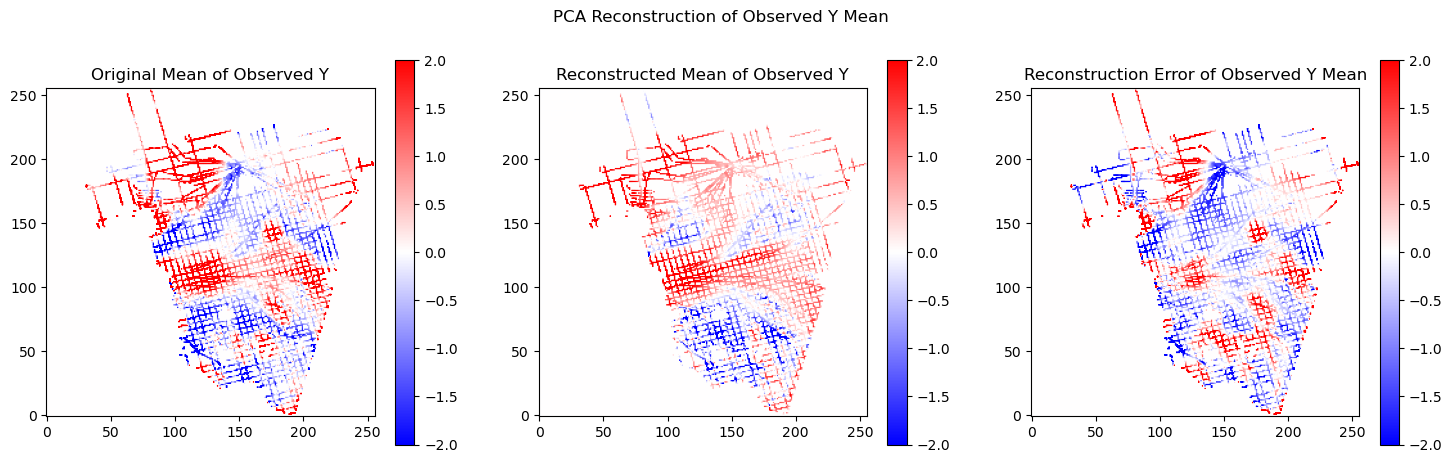

In [19]:
# getting the mean and covariance into the latent space
VT = pca_Y.components_ 
n_components = VT.shape[0]
Sigma_VT = np.zeros_like(VT.T) # (N, k)

for k in range(n_components):
    # Apply operator to each principal component
    Sigma_VT[:, k] = Sigma_op.matvec(VT[k, :])

cov_obs_latent = VT @ Sigma_VT
mu_obs_latent  = pca_Y.transform(Y_obs_mean.reshape(1,-1))

mu_obs_recons = pca_Y.inverse_transform(mu_obs_latent)
mu_obs_recons_img = mu_obs_recons.reshape(256, 256)

mu_obs_recons_err =  Y_obs_mean.flatten()-mu_obs_recons
mu_obs_recons_err_img = mu_obs_recons_err.reshape(256, 256)
plt.figure(figsize=(18, 5))
plt.subplot(1,3,2)
plt.imshow(mu_obs_recons_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstructed Mean of Observed Y')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,3,1)
plt.imshow(Y_obs_mean, cmap='bwr', vmin=-2, vmax=2)
plt.title('Original Mean of Observed Y')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,3,3)
plt.imshow(mu_obs_recons_err_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstruction Error of Observed Y Mean')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('PCA Reconstruction of Observed Y Mean')
plt.savefig('../figs/pca_reconstruction_observed_Y_mean.png', dpi=300)
plt.show()



In [20]:
from sklearn.preprocessing import StandardScaler
from src.optimization import log_prior_gradient
from scipy.optimize import minimize, Bounds


# solve an optimization problem: arg min \| obs - z @ V.T\|^2 - log p(z)
# find the z_optimal, which is the latent space for Y_obs_mean, regularized by the density of all z from the training data
y_latent_all = pca_Y.transform(Y_reshaped)
print(y_latent_all.shape)

# create a GMM for y_latent_all
gmm_latent = GMM(n_components=4, random_state=random_state)
# create a 0.8-0.2 train-test split for the latent space of Y
n_latent_samples = y_latent_all.shape[0]
indices = np.arange(n_latent_samples)
random_state.shuffle(indices)
split_point = int(0.8 * n_latent_samples)
train_indices = indices[:split_point]
test_indices = indices[split_point:]
y_latent_train = y_latent_all[train_indices]
y_latent_test = y_latent_all[test_indices]
scaler = StandardScaler()
y_latent_train_scaled = scaler.fit_transform(y_latent_train)
y_latent_test_scaled  = scaler.transform(y_latent_test)

gmm_latent.from_samples(y_latent_train_scaled)
log_likelihood = np.log(gmm_latent.to_probability_density(y_latent_test_scaled))

# check the fit on the test set
print(f"Average Log-Likelihood of GMM on Test Set: {np.mean(log_likelihood):.3f}")

def obs_latent_likelihood(obs, z, V):
    """Mean squared reconstruction error — scale-invariant."""
    residual = obs - z @ V
    return float(np.mean(residual**2))

def obs_latent_prior(z, gmm, scaler):
    """Log prior of z under the GMM (fitted in scaled space)."""
    z_scaled = scaler.transform(z.reshape(1, -1))             # (1, n_latent_features) for to_probability_density
    return float(np.log(gmm.to_probability_density(z_scaled)))

def grad_obs_latent_likelihood(obs, z, V):
    residual = obs - z @ V
    return (-2 / len(obs) * residual @ V.T).flatten()

def grad_obs_latent_prior(z, gmm, scaler):
    """Gradient of log prior w.r.t. z, with scaler chain rule correction."""
    z_scaled = scaler.transform(z.reshape(1, -1)).flatten()   # (n_latent_features,) for log_prior_gradient
    grad_scaled = log_prior_gradient(z_scaled, gmm)           # (n_latent_features,)
    return grad_scaled / scaler.scale_     

def objective(z, obs, V, beta=1):
    ll_val = obs_latent_likelihood(obs, z, V)
    prior_val = obs_latent_prior(z, gmm_latent, scaler)
    print(f" Likelihood: {ll_val:.3f}, Prior: {-prior_val:.3f}")
    return 1/beta * ll_val - prior_val

def gradient(z, obs, V, beta=1):
    return 1/beta * grad_obs_latent_likelihood(obs, z, V) - grad_obs_latent_prior(z, gmm_latent, scaler)

# # solve the optimization problem using L-BFGS
# beta_fit = 1e3
# z_init = gmm_latent.sample(1).flatten()  # start from a random sample from the GMM in latent space
# z_scaled = scaler.transform(z_init.reshape(1, -1))
# density = np.log(gmm_latent.to_probability_density(z_scaled))
# print(f"log-density at z_init: {density}")        # if ~0, that's your inf
# print(f"Scaler means: {scaler.mean_}")         # z_init=0 maps to -mean/std
# result = minimize(objective, z_init, 
#                   args=(Y_obs_mean.flatten(), pca_Y.components_, beta_fit),
#                   jac=gradient, 
#                   method='L-BFGS-B')
# z_optimal = result.x
# print("Optimization success:", result.success)
# print("Optimal latent z:", z_optimal)



(1042, 15)
Average Log-Likelihood of GMM on Test Set: -16.360


Density at init: [3.81516605e-06]
 Likelihood: 10.034, Prior: 12.477
 Likelihood: 10.081, Prior: 14.423
 Likelihood: 9.568, Prior: 12.620
 Likelihood: 9.548, Prior: 12.612
 Likelihood: 9.529, Prior: 12.612
 Likelihood: 9.524, Prior: 12.612
 Likelihood: 9.522, Prior: 12.613
 Likelihood: 9.518, Prior: 12.616
 Likelihood: 9.518, Prior: 12.616
 Likelihood: 9.518, Prior: 12.616
 Likelihood: 9.517, Prior: 12.616
 Likelihood: 9.517, Prior: 12.616
 Likelihood: 9.518, Prior: 12.616
 Likelihood: 9.518, Prior: 12.616
 Likelihood: 9.518, Prior: 12.616
 Likelihood: 9.518, Prior: 12.616
 Likelihood: 9.518, Prior: 12.616
Optimization success: True
CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations: 14
Function evaluations: 17
Final objective: 22.1337

Final MSE: 0.9518
Final prior -log p(z): 12.616
Final density: 0.000003
z_optimal_scaled: [ 3.430e-01  2.890e-01 -8.300e-02 -1.013e+00  2.230e-01 -3.420e-01
  1.080e-01  1.520e-01 -7.100e-02 -1.280e-01 -3.580e-01  1.330e-01
  5.700e-02  2.090e-0

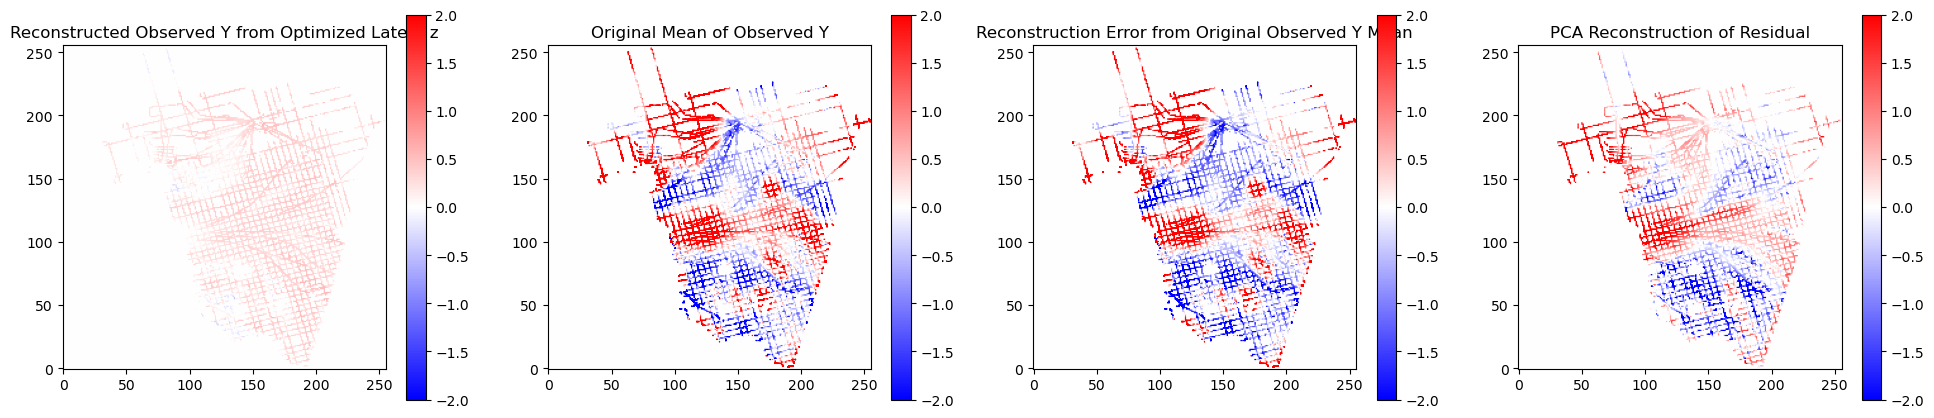

In [22]:
def objective_scaled(z_scaled, Y_obs, V, beta):
    """Objective in scaled z space — avoids scaler transform inside loop."""
    z_orig = scaler.inverse_transform(z_scaled.reshape(1, -1)).flatten()
    
    # Likelihood term (in original space)
    residual = Y_obs - z_orig @ V
    likelihood_term = np.mean(residual**2)
    
    # Prior term (directly in scaled space — no transform needed)
    density = gmm_latent.to_probability_density(z_scaled.reshape(1, -1))
    if density <= 0:
        prior_term = 1e6
    else:
        prior_term = -np.log(float(density))
    print(f" Likelihood: {likelihood_term/beta:.3f}, Prior: {prior_term:.3f}")
    return likelihood_term / beta + prior_term

# def gradient_scaled(z_scaled, Y_obs, V, beta):
#     z_orig = scaler.inverse_transform(z_scaled.reshape(1, -1)).flatten()
    
#     # Likelihood gradient in original space, then chain rule through scaler
#     grad_lik_orig = -2 * (Y_obs - z_orig @ V) @ V.T / len(Y_obs)
#     grad_lik_scaled = grad_lik_orig / scaler.scale_   # chain rule: dz_orig/dz_scaled = scale_
    
#     # Prior gradient directly in scaled space
#     grad_prior_scaled = log_prior_gradient(z_scaled, gmm_latent)
    
#     return grad_lik_scaled / beta + grad_prior_scaled

def gradient_scaled(z_scaled, Y_obs, V, beta):
    # --- Likelihood gradient (analytical) ---
    z_orig = scaler.inverse_transform(z_scaled.reshape(1, -1)).flatten()
    residual = Y_obs - z_orig @ V
    grad_lik_orig = -2 * (residual @ V.T) / len(Y_obs)
    grad_lik_scaled = grad_lik_orig * scaler.scale_

    # --- Prior gradient (central differences) ---
    eps = 1e-4
    grad_prior = np.zeros_like(z_scaled)
    for i in range(len(z_scaled)):
        z_plus = z_scaled.copy();  z_plus[i] += eps
        z_minus = z_scaled.copy(); z_minus[i] -= eps
        f_plus  = -np.log(float(gmm_latent.to_probability_density(z_plus.reshape(1,-1)))  + 1e-300)
        f_minus = -np.log(float(gmm_latent.to_probability_density(z_minus.reshape(1,-1))) + 1e-300)
        grad_prior[i] = (f_plus - f_minus) / (2 * eps)

    return grad_lik_scaled / beta + grad_prior


# Initialize at GMM component mean — already in scaled space, density is maximal
best_k = np.argmax(gmm_latent.priors)
z_init_scaled = gmm_latent.means[best_k].copy()
# z_init_scaled = scaler.transform(gmm_latent.sample(1).flatten().reshape(1, -1)).flatten()  # average of component means in scaled space
print(f"Density at init: {gmm_latent.to_probability_density(z_init_scaled.reshape(1,-1))}")

# Bounds in scaled space: ±4 std (which is just ±4 since data is standardized)
lb_scaled = np.full(15, -5.0)
ub_scaled = np.full(15,  5.0)

result = minimize(objective_scaled, z_init_scaled,
                  args=(Y_obs_mean.flatten(), pca_Y.components_, 0.1),
                  jac=gradient_scaled,
                  method='L-BFGS-B',
                  bounds=Bounds(lb_scaled, ub_scaled))

# Convert optimal back to original space
z_optimal_scaled = result.x
z_optimal = scaler.inverse_transform(z_optimal_scaled.reshape(1, -1)).flatten()
print("Optimization success:", result.success)

print(result.message)
print(f"Iterations: {result.nit}")
print(f"Function evaluations: {result.nfev}")
print(f"Final objective: {result.fun:.4f}")

# Check the actual solution quality regardless of success flag
z_optimal_scaled = result.x
z_optimal = scaler.inverse_transform(z_optimal_scaled.reshape(1, -1)).flatten()

Y_recon = z_optimal @ pca_Y.components_ + pca_Y.mean_
mse = np.mean((Y_obs_mean.flatten() - Y_recon)**2)
final_density = gmm_latent.to_probability_density(z_optimal_scaled.reshape(1, -1))
final_prior = -np.log(float(final_density))

print(f"\nFinal MSE: {mse:.4f}")
print(f"Final prior -log p(z): {final_prior:.3f}")
print(f"Final density: {float(final_density):.6f}")
print(f"z_optimal_scaled: {z_optimal_scaled.round(3)}")

# error = check_grad(
#     lambda z: objective_scaled(z, Y_obs_mean.flatten(), pca_Y.components_, 1.0),
#     lambda z: gradient_scaled(z, Y_obs_mean.flatten(), pca_Y.components_, 1.0),
#     z_init_scaled.copy()
# )
# print(f"Gradient error (should be < 1e-4): {error:.6f}")

# reconstruct the Y_obs_mean from the optimized latent z
Y_obs_reconstructed_optimal = z_optimal @ pca_Y.components_
Y_obs_reconstructed_optimal_img = Y_obs_reconstructed_optimal.reshape(256, 256)

plt.figure(figsize=(24, 5))
plt.subplot(1,4,1)
plt.imshow(Y_obs_reconstructed_optimal_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstructed Observed Y from Optimized Latent z')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,4,2)
plt.imshow(Y_obs_mean.reshape(256, 256), cmap='bwr', vmin=-2, vmax=2)
plt.title('Original Mean of Observed Y')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,4,3)
plt.imshow(Y_obs_mean.reshape(256, 256) - Y_obs_reconstructed_optimal_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstruction Error from Original Observed Y Mean')
plt.colorbar()
plt.gca().invert_yaxis()
# projecting the residue to PCA space and show the reconstruction
residual = Y_obs_mean.flatten() - Y_obs_reconstructed_optimal
residual_latent = pca_Y.transform(residual.reshape(1, -1)).flatten()
residual_recon = pca_Y.inverse_transform(residual_latent.reshape(1, -1)).reshape(256, 256)
plt.subplot(1,4,4)
plt.imshow(residual_recon, cmap='bwr', vmin=-2, vmax=2)
plt.title('PCA Reconstruction of Residual')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()



In [23]:
residual_latent = residual_latent.reshape(-1, 1)  # shape (15, 1)
residual_latent_outer = residual_latent @ residual_latent.T  # shape (15, 15)
variance_latent = np.diag(pca_Y.explained_variance_)  # shape (15, 15)

lambda1 = 1
lambda2 = 1
cov_obs_latent = lambda1 * residual_latent_outer + lambda2 * variance_latent
print("first 5x5 block of cov_obs_latent:")
print(cov_obs_latent[:4, :4])
# Should be positive definite — all eigenvalues > 0
eigvals = np.linalg.eigvalsh(cov_obs_latent)
print("min eigenvalue:", eigvals.min())  # must be > 0

# assign mean value
mu_obbs_latent = z_optimal

first 5x5 block of cov_obs_latent:
[[7392.92817769  560.26066716 -432.69577791  518.64738077]
 [ 560.26066716 1407.1425016  -615.67162085  737.96993147]
 [-432.69577791 -615.67162085  757.35234706 -569.94269326]
 [ 518.64738077  737.96993147 -569.94269326  767.38681767]]
min eigenvalue: 8.173579663940924


conditioned indices are:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


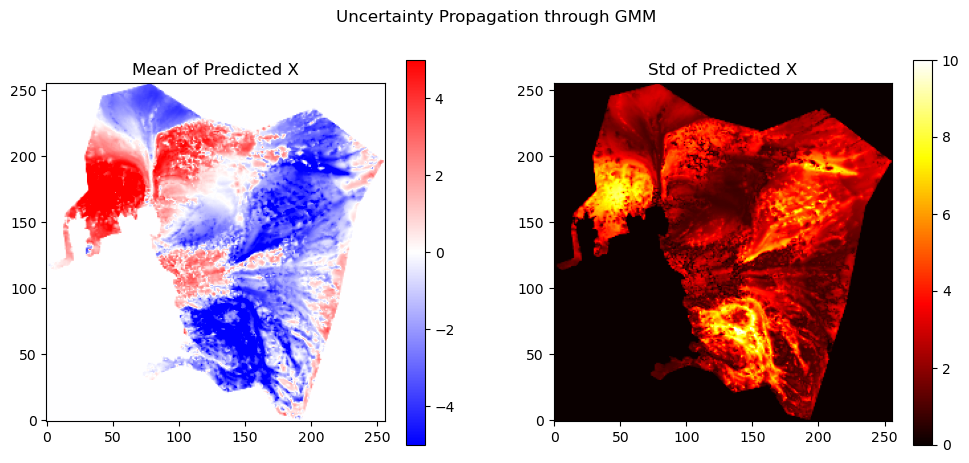

In [24]:
# propagate the observational uncertainty through the GMM to get the uncertainty in X
gmm_propagated = propagate_uncertainty(mu_obs_latent.T, cov_obs_latent, gmm, np.arange(ndim_Y), XY_train[:,:ndim_Y])

# sample from gmm_propagated to get the distribution of X
n_samples = 300
X_samples = gmm_propagated.sample(n_samples)
X_samples_ori = np.zeros((256*256, n_samples))
for i, sample in enumerate(X_samples):
    X_samples_ori[:,i] = pca_X.inverse_transform(sample)

# visualize the mean and variance
X_samples_mean = np.mean(X_samples_ori, axis=1).reshape(256, 256)
X_samples_std = np.std(X_samples_ori, axis=1).reshape(256, 256)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_samples_mean, cmap='bwr', vmin=-5, vmax=5)
plt.title('Mean of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(X_samples_std, cmap='hot', vmin=0, vmax=10)
plt.title('Std of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('Uncertainty Propagation through GMM')
plt.show()

# clear x_samples_ori to save memory
del X_samples_ori

# Finding Maximum A Posteriori in the latent space

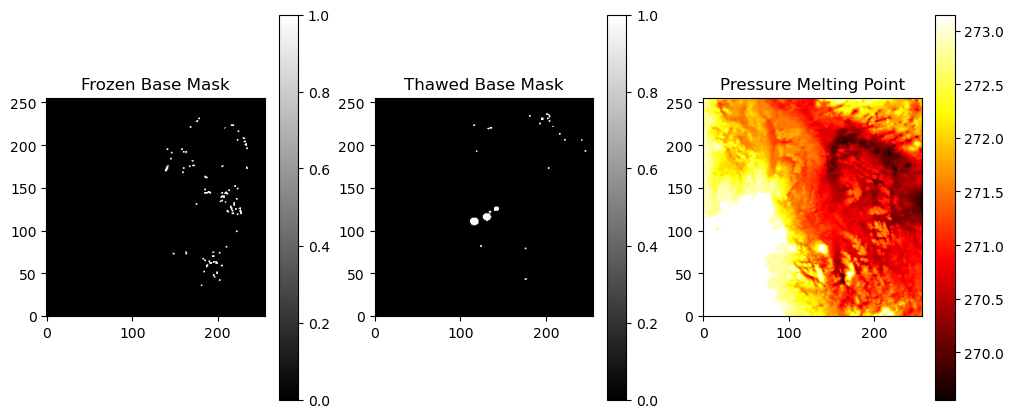

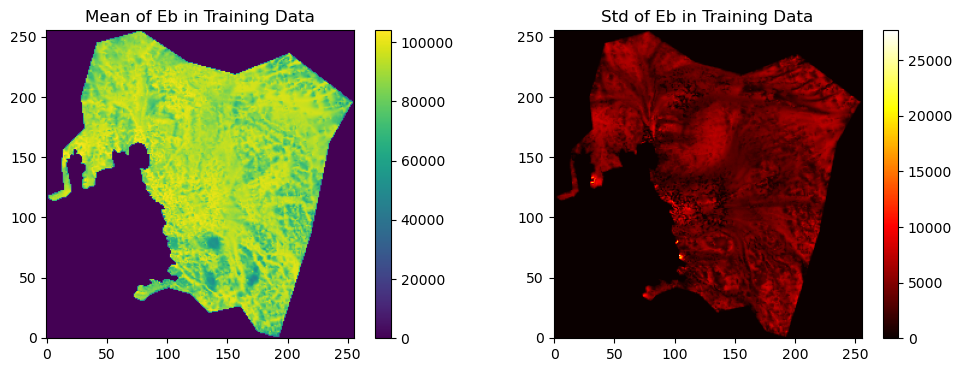

In [25]:
from src.ice import compute_pmp
from src.optimization import log_posterior_gradient, log_posterior
from src.optimization import log_posterior_hessian


# load the thawed base and frozen base data
frozen_base_filename = folder + "../../basal-frozen-mask/frozen_mask.mat"
thawed_base_filename = folder + "../../basal-water-mask/water_mask.mat"
frozen_mask = scipy.io.loadmat(frozen_base_filename)['frozen_mask']
thawed_mask = scipy.io.loadmat(thawed_base_filename)['water_mask']
frozen_mask_data = frozen_mask['data'][0][0]
thawed_mask_data = thawed_mask['data'][0][0]

Eb_mean_data = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0
Eb_mean_data = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
pmp = compute_pmp(H)

# visualize both and pmp
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(frozen_mask_data, cmap='gray')
plt.title('Frozen Base Mask')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 2)
plt.imshow(thawed_mask_data, cmap='gray')
plt.title('Thawed Base Mask')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 3)
plt.imshow(pmp.reshape(256,256), cmap='hot')
plt.title('Pressure Melting Point')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

# visualize the mean and std of Eb
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(Eb_mean_data, cmap='viridis')
plt.title('Mean of Eb in Training Data')    
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(Eb_std_data, cmap='hot')
plt.title('Std of Eb in Training Data')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

# into a vector
Eb_mean_data = Eb_mean_data.flatten()
Eb_std_data = Eb_std_data.flatten()
frozen_mask_data = frozen_mask_data.flatten()
thawed_mask_data = thawed_mask_data.flatten()


In [31]:

from src.optimization import enthalpy_to_temperature, finite_difference_check
import torch
import torch.optim as optim

# set fractional area to 1 for all locations (assumption for now, can be relaxed later)
thawed_fractional_area = np.zeros_like(thawed_mask_data)
frozen_fractional_area = np.zeros_like(frozen_mask_data)
thawed_fractional_area[thawed_mask_data == 1] = 1.0
frozen_fractional_area[frozen_mask_data == 1] = 1.0

# get the mean of the Eb distribution from gmm_propagated 
# as the initial condition for the optimization

VT_X = pca_X.components_
init_Eb_ori = X_samples_mean.flatten().reshape(1, -1)
init_Eb_reduced = pca_X.transform(init_Eb_ori)
init_Eb_ori = init_Eb_ori.T.flatten()
init_Eb_reduced = init_Eb_reduced.T.flatten()

beta = 0.5
init_Eb_reduced = torch.from_numpy(init_Eb_reduced)
Tpmp = torch.from_numpy(pmp)
dw = torch.from_numpy(thawed_fractional_area)
df = torch.from_numpy(frozen_fractional_area)

# check the forward terms
log_posterior_val = log_posterior(init_Eb_reduced, VT_X, gmm_propagated,
              beta, Tpmp, Eb_mean_data, Eb_std_data, thawed_fractional_area, frozen_fractional_area,
              verbose=True, Eb_epsilon=Eb_standardize_epsilon)


# check the gradient terms
log_posterior_grad_val = log_posterior_gradient(init_Eb_reduced, VT_X, gmm_propagated, 
                                                beta, Tpmp, Eb_mean_data, Eb_std_data, dw, df, Eb_epsilon=Eb_standardize_epsilon)
print(log_posterior_grad_val)

# do a finite difference check for the gradient
log_posterior_grad_val_fd = finite_difference_check(init_Eb_reduced, VT_X, gmm_propagated,
                                                beta, Tpmp, Eb_mean_data, Eb_std_data, dw, df, Eb_epsilon=Eb_standardize_epsilon)
print(log_posterior_grad_val_fd)


Log Likelihood Thawed: -2916.312
Log Likelihood Frozen: -15.193
Log Prior: -83.431
[ 1.57566554  3.4810184   0.91699267  1.22884729  1.19678238  1.66506533
 -0.63319683 -1.14068649  1.34041758 -0.04501918 -1.25223046 -0.90393267
  0.69697028  0.25161073 -2.68122365 -0.61309547  1.45927983  1.60404346
  0.1859267   1.59032427]
[ 1.57566549  3.48101842  0.91699276  1.2288473   1.19678232  1.66506536
 -0.63319678 -1.14068653  1.34041766 -0.04501915 -1.25223046 -0.90393273
  0.69697023  0.25161069 -2.68122365 -0.6130954   1.45927982  1.60404343
  0.18592673  1.59032429]


In [32]:
# start the optimization using L-BFGS
n_iter = 20
X = init_Eb_reduced.clone().requires_grad_(True)
optimizer = optim.LBFGS([X], lr=0.5, max_iter=n_iter)

saved_snapshots = []

def closure():
    """ closure function for L-BFGS optimizer
    """
    optimizer.zero_grad()
    X_detached = X.detach()

    # function value: negative log posterior
    value = -log_posterior(X_detached, VT_X, gmm_propagated,
                           beta, Tpmp, Eb_mean_data, Eb_std_data,
                           thawed_fractional_area, frozen_fractional_area,
                           verbose=False, Eb_epsilon=Eb_standardize_epsilon)
    # gradient
    grad = -log_posterior_gradient(X_detached, VT_X, gmm_propagated, 
                                   beta, Tpmp, Eb_mean_data, Eb_std_data, 
                                   dw, df, Eb_epsilon=Eb_standardize_epsilon)
    # Convert gradient to torch tensor if needed
    if not isinstance(grad, torch.Tensor):
        grad = torch.tensor(grad, dtype=X.dtype, device=X.device)
    
    X.grad = grad
    return value

for i in range(n_iter):
    print(f"Starting iteration {i+1}/{n_iter}...")
    optimizer.step(closure)
    # monitor the loss (or the neg log posterior)
    with torch.no_grad():
        current_loss = -log_posterior(X, VT_X, gmm_propagated,
                                     beta, Tpmp, Eb_mean_data, Eb_std_data,
                                     thawed_fractional_area, frozen_fractional_area,
                                     verbose=False, Eb_epsilon=Eb_standardize_epsilon)
        print(f"Iteration {i+1}/{n_iter}, Negative Log Posterior: {current_loss.item():.4f}")
    # save the first n iterations and the last iteration
    if i < 9 or i == n_iter - 1:
        saved_snapshots.append(X.detach().cpu().numpy().copy())

    # save the hessian matrix at the last iteration for analysis
    if i == n_iter - 1:
        optimized_X = X.detach().requires_grad_(True)   # fresh leaf, grad-enabled
        hessian = log_posterior_hessian(
            optimized_X, VT_X, gmm_propagated,
            beta, Tpmp, Eb_mean_data, Eb_std_data,
            thawed_fractional_area, frozen_fractional_area,
            Eb_epsilon=Eb_standardize_epsilon

)

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 1115.8275
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 1075.8814
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 1075.5844
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 1075.5863
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 1078.3864
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 1076.4688
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 1075.6931
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 1075.6680
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 1076.0705
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 1075.4480
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 1075.7489
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 1075.4131
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 1

In [33]:
# 0 to nan
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(float)
model_bound_data_ori[model_bound_data_ori == 0] = np.nan

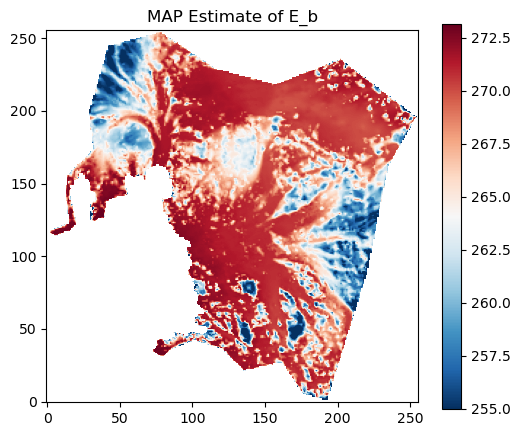

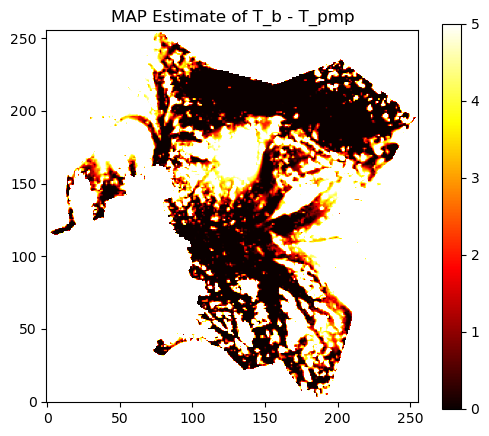

In [34]:
X_optimized = X.detach().numpy()

Eb_MAP = pca_X.inverse_transform(X_optimized.reshape(1, -1)).reshape(256, 256)
Eb_MAP_ori = torch.from_numpy(Eb_MAP * Eb_std_data.reshape(256, 256) + Eb_mean_data.reshape(256, 256))
Tb_MAP = enthalpy_to_temperature(Eb_MAP_ori.flatten(), Tpmp.flatten()).reshape(256, 256).numpy()
# reverse standardize and back to temperature 
plt.figure(figsize=(6, 5))
plt.imshow(Tb_MAP * model_bound_data_ori, cmap='RdBu_r', vmin=255, vmax=273.15)
plt.title('MAP Estimate of E_b')
plt.colorbar()
plt.gca().invert_yaxis()
dT_to_pmp = Tpmp.reshape(256,256) - Tb_MAP
# plot as contour lines
plt.figure(figsize=(6, 5))
plt.imshow(dT_to_pmp * model_bound_data_ori, cmap='hot', vmin=0, vmax=5)
plt.title('MAP Estimate of T_b - T_pmp')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

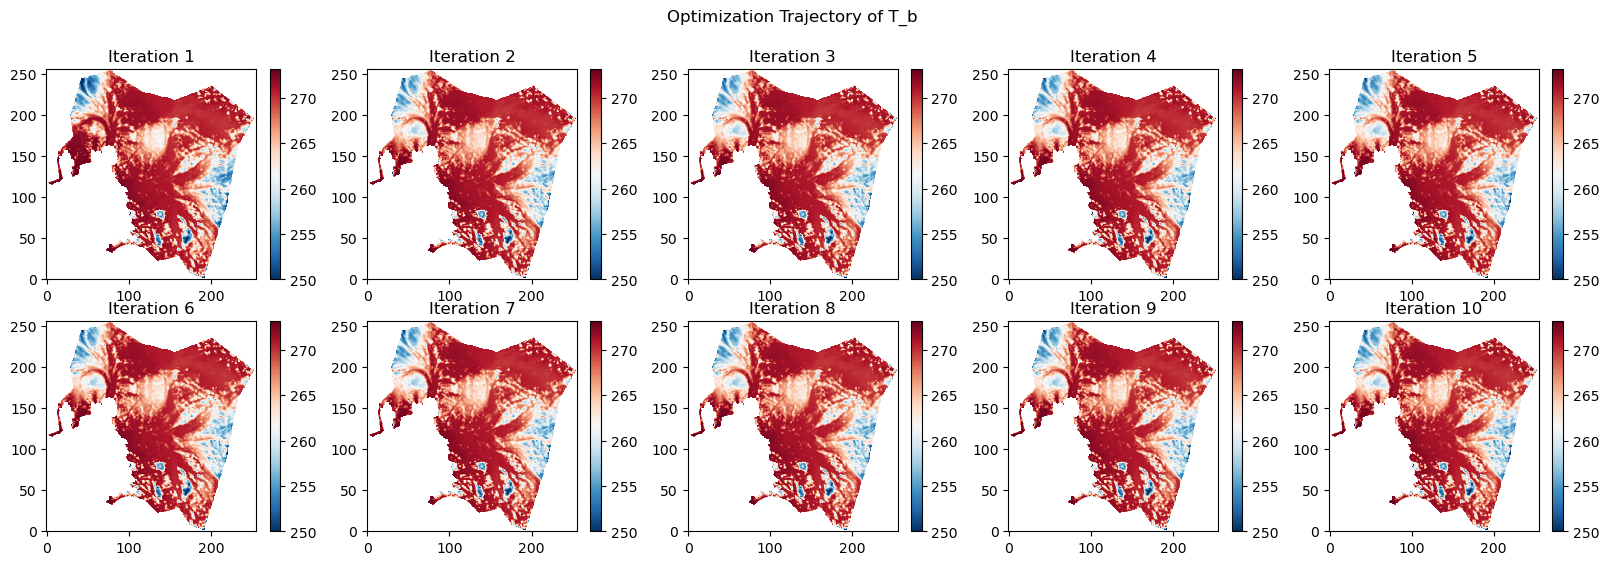

In [35]:
# plot all the snapshots to see the optimization trajectory
n_snapshots = len(saved_snapshots)
plt.figure(figsize=(20, 6))
for i, snapshot in enumerate(saved_snapshots):
    Eb_snapshot = pca_X.inverse_transform(snapshot.reshape(1, -1)).reshape(256, 256)
    Eb_snapshot_ori = torch.from_numpy(Eb_snapshot * Eb_std_data.reshape(256, 256) + Eb_mean_data.reshape(256, 256))
    Tb_snapshot = enthalpy_to_temperature(Eb_snapshot_ori.flatten(), Tpmp.flatten()).reshape(256, 256)
    plt.subplot(2, n_snapshots//2, i+1)
    plt.imshow(Tb_snapshot * model_bound_data_ori, cmap='RdBu_r', vmin=250, vmax=273.15)
    
    plt.title(f'Iteration {i+1}')
    plt.colorbar()
    plt.gca().invert_yaxis()
plt.suptitle('Optimization Trajectory of T_b')
plt.show()

# Hamiltonian Monte Carlo

In [37]:
# from src.hamiltonianMC import HMCPotential, CustomEnergy, create_potential_fn, run_hmc
import pyro.infer.mcmc as mcmc

class CustomEnergy(torch.autograd.Function):
    """
    Bridges the pure PyTorch/NumPy hybrid log-posterior directly into Pyro.
    """
    @staticmethod
    def forward(ctx, z, V, gmm, beta, Tpmp, Eb_mean, Eb_std, dw, df):
        ctx.save_for_backward(z)
        ctx.V = V
        ctx.gmm = gmm
        ctx.beta = beta
        ctx.Tpmp = Tpmp
        ctx.Eb_mean = Eb_mean
        ctx.Eb_std = Eb_std
        ctx.dw = dw
        ctx.df = df
        ctx.Eb_epsilon = Eb_standardize_epsilon
        
        z_np = z.detach().cpu().numpy()
        
        with torch.no_grad():
            lp = log_posterior(z_np, V, gmm, beta, Tpmp, Eb_mean, Eb_std, dw, df, Eb_epsilon=Eb_standardize_epsilon)
            if isinstance(lp, torch.Tensor):
                lp = lp.item()
                
        return torch.tensor(-lp, dtype=z.dtype, device=z.device)

    @staticmethod
    def backward(ctx, grad_output):
        z, = ctx.saved_tensors
        z_np = z.detach().cpu().numpy()
        
        # CRITICAL FIX: Re-enable gradient tracking so the internal AD graph can build!
        with torch.enable_grad():
            grad_np = log_posterior_gradient(
                z_np, ctx.V, ctx.gmm, ctx.beta, ctx.Tpmp, 
                ctx.Eb_mean, ctx.Eb_std, ctx.dw, ctx.df, ctx.Eb_epsilon
            )
        
        grad_potential = -grad_np
        grad_tensor = torch.tensor(grad_potential, dtype=z.dtype, device=z.device)
        
        return grad_tensor * grad_output, None, None, None, None, None, None, None, None
# 1. Compute Covariance (Inverse negative Hessian) and its Cholesky factor
H_pot = torch.tensor(-hessian, dtype=torch.float64)
# stable matrix inversion
jitter = 1e-5 * torch.eye(H_pot.shape[0], dtype=torch.float64)
cov_matrix = torch.inverse(H_pot + jitter)

# L is the lower triangular Cholesky factor
L = torch.linalg.cholesky(cov_matrix)
X_opt_tensor = torch.tensor(X_optimized, dtype=torch.float64)

# 2. Create the Whitened Potential Function
def potential_fn_whitened(params_dict):
    # u is the perfectly isotropic variable that Pyro is exploring
    u = params_dict["u"]
    
    # Reparameterization Trick: Warp 'u' back into your highly correlated 'z' space
    # z = MAP + L * u
    z = X_opt_tensor + torch.matmul(L, u)
    
    # Pass 'z' to our custom hybrid autograd bridge
    return CustomEnergy.apply(
        z, VT_X, gmm_propagated, beta, Tpmp, 
        Eb_mean_data, Eb_std_data, thawed_fractional_area, frozen_fractional_area
    )

# 3. Configure NUTS
nuts_kernel = mcmc.NUTS(
    potential_fn=potential_fn_whitened,
    adapt_step_size=True,       # NUTS easily finds a large step size in spherical space
    adapt_mass_matrix=False,    # Keep mass matrix as Identity!
    max_tree_depth=10           # Let it run deep if it wants, it will be fast now
)

# 4. Initialize and Run MCMC
# Since z_initial = MAP, the corresponding u_initial is exactly a vector of 0s
initial_params = {"u": torch.zeros_like(X_opt_tensor)}

num_samples = 4000
warmup_steps = 1000  # Space is perfectly isotropic now, warmup is incredibly fast

mcmc_run = mcmc.MCMC(
    nuts_kernel,
    num_samples=num_samples,
    warmup_steps=warmup_steps,
    initial_params=initial_params
)

print(f"Starting HMC sampling: {num_samples} samples, {warmup_steps} warmup...")
mcmc_run.run(extra_fields=("potential_energy",))
torch.save(mcmc_run, "../data/posterior-hmc-models/mcmc_run.pt")


Starting HMC sampling: 4000 samples, 1000 warmup...


Sample: 100%|██████████| 5000/5000 [2:22:54,  1.71s/it, step size=2.66e-02, acc. prob=0.788]


In [ ]:
# get the samples and their log probabilities

# u_samples: shape (N, M) numpy array
u_samples_tensor = torch.tensor(u_samples, dtype=torch.float64)

num_samples = u_samples_tensor.shape[0]
log_probs = []

with torch.no_grad():
    for i in range(num_samples):
        u_i = u_samples_tensor[i]  # shape (M,)
        
        # potential_fn_whitened returns NEGATIVE log prob → negate it
        neg_lp = potential_fn_whitened({"u": u_i})
        log_probs.append(-neg_lp.item())

log_probs = np.array(log_probs)  # shape: (N,)

plt.figure(figsize=(8, 5))
plt.hist(log_probs, bins=50, color='blue', alpha=0.7)
plt.xlabel("Log Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Log Probabilities")

In [ ]:
# Apply the reverse transformation to the samples: z_samples = MAP + u_samples @ L^T
hmc_samples = X_optimized + (u_samples @ L.numpy().T)
print(f"HMC Sampling Complete. Extracted shape: {hmc_samples.shape}")
# =============================================================================
# 3. Post-Processing: Transform Samples to Temperature Space
# =============================================================================
print("Transforming HMC samples back to physical temperature space...")

# Transform all latent samples back to normalized physical space
# pca_X.inverse_transform expects shape (n_samples, n_features)
Eb_samples_norm = pca_X.inverse_transform(hmc_samples) 

# Unstandardize
Eb_std_flat = Eb_std_data.flatten()
Eb_mean_flat = Eb_mean_data.flatten()
Eb_samples_ori = Eb_samples_norm * Eb_std_flat + Eb_mean_flat

Tb_samples = np.zeros_like(Eb_samples_ori)
Tpmp_flat = Tpmp.flatten()

for i in range(num_samples):
    # Depending on whether enthalpy_to_temperature expects torch tensors or numpy arrays
    Eb_i = torch.from_numpy(Eb_samples_ori[i])
    Tpmp_i = torch.from_numpy(Tpmp_flat) if isinstance(Tpmp_flat, np.ndarray) else Tpmp_flat
    
    Tb_samples[i] = enthalpy_to_temperature(Eb_i, Tpmp_i).numpy()

# Calculate Standard Deviation directly across the sample axis
posterior_std_Tb = np.std(Tb_samples, axis=0).reshape(256, 256)

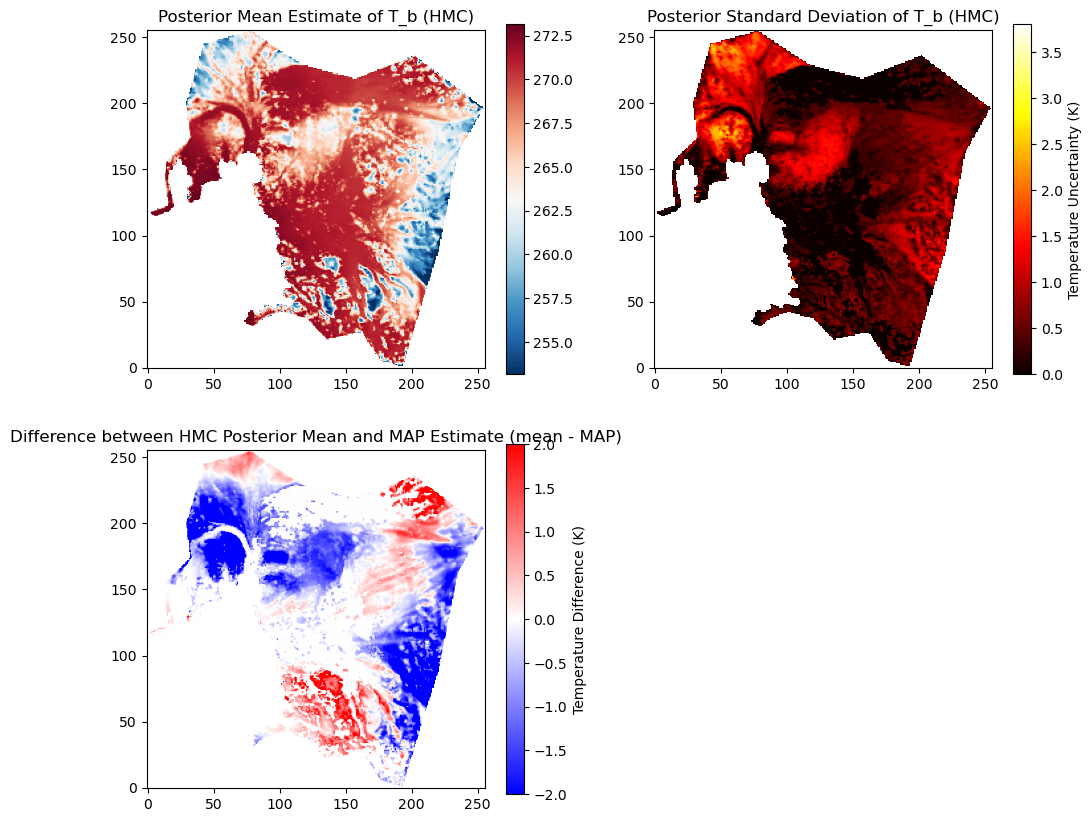

ERROR 1: PROJ: internal_proj_create_from_database: /home/donglaiyang/anaconda3/envs/SciML/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_create_from_database: /home/donglaiyang/anaconda3/envs/SciML/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


In [115]:
# =============================================================================
# 4. Plotting the mean and Uncertainty
# =============================================================================
# Calculate Standard Deviation directly across the sample axis
# if Tb_samples is not found, load it
try:
    posterior_std_Tb = np.std(Tb_samples, axis=0).reshape(256, 256)
    posterior_mean_Tb = np.mean(Tb_samples, axis=0).reshape(256, 256)
except NameError:
    data = np.load("data/posterior-hmc-samples/hmc_samples.npz")
    Tb_samples = data['Tb_samples']
    posterior_mean_Tb = np.mean(Tb_samples, axis=0).reshape(256, 256)
    posterior_std_Tb = np.std(Tb_samples, axis=0).reshape(256, 256)
mask_domain = model_bound_data['in_domain_mask']

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(posterior_mean_Tb * model_bound_data_ori, cmap='RdBu_r', vmin=253.15, vmax=273.15)
plt.title('Posterior Mean Estimate of T_b (HMC)')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(2, 2, 2)
plt.imshow(posterior_std_Tb * model_bound_data_ori, cmap='hot', vmin=0)
plt.title('Posterior Standard Deviation of T_b (HMC)')
plt.colorbar(label='Temperature Uncertainty (K)')
plt.gca().invert_yaxis()
plt.subplot(2, 2, 3)
plt.imshow((posterior_mean_Tb - Tb_MAP) * model_bound_data_ori, cmap='bwr', vmin=-2, vmax=2)
plt.title('Difference between HMC Posterior Mean and MAP Estimate (mean - MAP)')
plt.colorbar(label='Temperature Difference (K)')
plt.gca().invert_yaxis()
plt.savefig("figs/posterior_hmc.png", dpi=300)
plt.show()

# save the sampled data
np.savez("data/posterior-hmc-samples/hmc_samples.npz", Tb_samples=Tb_samples, posterior_mean_Tb=posterior_mean_Tb, posterior_std_Tb=posterior_std_Tb, x_coord=x_coord, y_coord=y_coord)

# save the mean and std separately as netcdf files with coordinates
x_coord_1d = np.array(x_coord).squeeze()   # (1, N) → (N,)
y_coord_1d = np.array(y_coord).squeeze()   # (1, N) → (N,)
posterior_mean_Tb[mask_domain == 0] = np.nan
posterior_std_Tb[mask_domain == 0] = np.nan

ds = xr.Dataset(
    {
        "posterior_mean_Tb": (("y", "x"), posterior_mean_Tb),
        "posterior_std_Tb":  (("y", "x"), posterior_std_Tb),
    },
    coords={
        "x": ("x", x_coord_1d),   # explicitly declare dim name
        "y": ("y", y_coord_1d),
    }
)
ds.rio.write_crs("EPSG:3031", inplace=True)
ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)


# Export each variable as a separate GeoTIFF
ds["posterior_mean_Tb"].rio.to_raster("data/posterior_mean_Tb.tif")
ds["posterior_std_Tb"].rio.to_raster("data/posterior_std_Tb.tif")
# save MAP as well
Tb_MAP[mask_domain == 0] = np.nan
ds_map = xr.Dataset(
    {
        "Tb_MAP": (("y", "x"), Tb_MAP),
    },
    coords={
        "x": ("x", x_coord_1d),   # explicitly declare dim name
        "y": ("y", y_coord_1d),
    }
)
ds_map.rio.write_crs("EPSG:3031", inplace=True)
ds_map.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
ds_map["Tb_MAP"].rio.to_raster("data/Tb_MAP.tif")

# save the posterior mean and std as .mat files
scipy.io.savemat("data/posterior_mean_Tb.mat", {"posterior_mean_Tb": posterior_mean_Tb})
scipy.io.savemat("data/posterior_std_Tb.mat", {"posterior_std_Tb": posterior_std_Tb})

--- HMC Sampling Metrics ---
Total Samples Drawn: 4000
Mean ESS across all dimensions: 1680.21
Minimum ESS (Worst mixing dimension): 656.92
Maximum ESS (Best mixing dimension): 3093.09
Post-Burn-in Mean ESS: 1497.07
Post-Burn-in Min ESS: 575.12


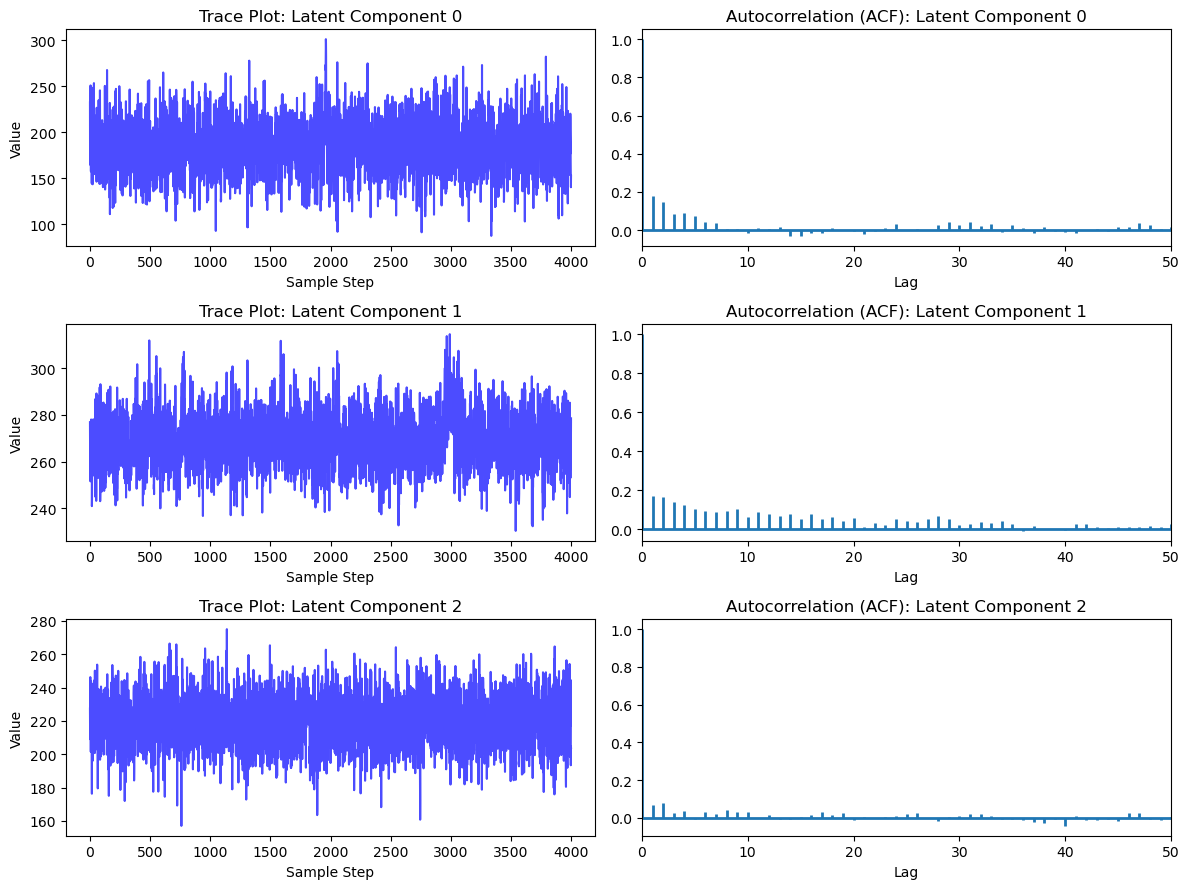

In [116]:
import pyro.ops.stats as stats

samples_tensor = torch.tensor(hmc_samples).unsqueeze(0) 
ess = stats.effective_sample_size(samples_tensor).numpy()

print(f"--- HMC Sampling Metrics ---")
print(f"Total Samples Drawn: {hmc_samples.shape[0]}")
print(f"Mean ESS across all dimensions: {ess.mean():.2f}")
print(f"Minimum ESS (Worst mixing dimension): {ess.min():.2f}")
print(f"Maximum ESS (Best mixing dimension): {ess.max():.2f}")

# Slice off the wandering phase
stable_samples = hmc_samples[400:]

# Re-run the ESS calculation on stable_samples
samples_tensor = torch.tensor(stable_samples).unsqueeze(0) 
ess = stats.effective_sample_size(samples_tensor).numpy()
print(f"Post-Burn-in Mean ESS: {ess.mean():.2f}")
print(f"Post-Burn-in Min ESS: {ess.min():.2f}")

# 2. Plot Trace and Autocorrelation for the first 3 latent dimensions
n_dims_to_plot = min(3, hmc_samples.shape[1])
fig, axes = plt.subplots(n_dims_to_plot, 2, figsize=(12, 3 * n_dims_to_plot))

for i in range(n_dims_to_plot):
    # Left Column: Trace Plot
    axes[i, 0].plot(hmc_samples[:, i], alpha=0.7, color='b')
    axes[i, 0].set_title(f"Trace Plot: Latent Component {i}")
    axes[i, 0].set_ylabel("Value")
    axes[i, 0].set_xlabel("Sample Step")
    
    # Right Column: Autocorrelation (ACF) Plot
    # We must mean-center the data for plt.acorr
    centered_data = hmc_samples[:, i] - np.mean(hmc_samples[:, i])
    axes[i, 1].acorr(centered_data, maxlags=50, usevlines=True, normed=True, lw=2)
    axes[i, 1].set_title(f"Autocorrelation (ACF): Latent Component {i}")
    axes[i, 1].set_xlim(0, 50)
    axes[i, 1].set_xlabel("Lag")

plt.tight_layout()
plt.savefig("figs/hmc_diagnostics.png", dpi=300)
plt.show()